# Cognifyz Machine Learning Internship

## Task 3 — Cuisine Classification

### Objective

Develop a machine learning classification model to classify
restaurants based on their cuisines.

### Approach

The Cuisines column contains multiple cuisines in some records.
Therefore, the first cuisine listed for each restaurant will be
used as the primary cuisine for classification.

Because some cuisines have very few observations, rare classes
will be grouped into an "Other" category to make the multiclass
classification problem more practical and stable.

### Important

The original Cuisines column will not be used as an input feature
because it directly contains the target information.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [2]:

df = pd.read_csv(
    "../outputs/results/cleaned_restaurant_dataset.csv"
)

print("Dataset shape:", df.shape)

Dataset shape: (9551, 22)


In [3]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,Primary Cuisine
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Yes,No,No,No,3,4.8,Dark Green,Excellent,314,French
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Yes,No,No,No,3,4.5,Dark Green,Excellent,591,Japanese
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Yes,No,No,No,4,4.4,Green,Very Good,270,Seafood
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,No,No,No,No,4,4.9,Dark Green,Excellent,365,Japanese
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Yes,No,No,No,4,4.8,Dark Green,Excellent,229,Japanese


In [4]:
print("Missing cuisines:", df["Cuisines"].isna().sum())
print("Unique cuisine strings:", df["Cuisines"].nunique())

Missing cuisines: 0
Unique cuisine strings: 1826


In [5]:
df["Primary Cuisine"] = (
    df["Cuisines"]
    .fillna("Unknown")
    .astype(str)
    .str.split(",")
    .str[0]
    .str.strip()
)

In [6]:
df[
    ["Cuisines", "Primary Cuisine"]
].head(20)

,Cuisines,Primary Cuisine
0,"French, Japanese, Desserts",French
1,Japanese,Japanese
2,"Seafood, Asian, Filipino, Indian",Seafood
3,"Japanese, Sushi",Japanese
4,"Japanese, Korean",Japanese
5,Chinese,Chinese
6,"Asian, European",Asian
7,"Seafood, Filipino, Asian, European",Seafood
8,"European, Asian, Indian",European
9,Filipino,Filipino


In [7]:
df["Primary Cuisine"] = (
    df["Primary Cuisine"]
    .str.strip()
    .str.title()
)

In [8]:
df["Primary Cuisine"].value_counts().head(20)

Primary Cuisine
North Indian    2992
Chinese          855
Fast Food        672
Bakery           621
Cafe             617
American         278
South Indian     262
Mithai           246
Street Food      236
Continental      235
Italian          234
Pizza            232
Mughlai          215
Ice Cream        178
Desserts         150
Burger           116
Biryani          112
Raw Meats        110
Beverages         79
Finger Food       78
Name: count, dtype: int64

In [9]:
cuisine_counts = (
    df["Primary Cuisine"]
    .value_counts()
)

cuisine_counts.head(20)

Primary Cuisine
North Indian    2992
Chinese          855
Fast Food        672
Bakery           621
Cafe             617
American         278
South Indian     262
Mithai           246
Street Food      236
Continental      235
Italian          234
Pizza            232
Mughlai          215
Ice Cream        178
Desserts         150
Burger           116
Biryani          112
Raw Meats        110
Beverages         79
Finger Food       78
Name: count, dtype: int64

In [10]:
cuisine_counts = (
    df["Primary Cuisine"]
    .value_counts()
)

cuisine_counts.head(20)

Primary Cuisine
North Indian    2992
Chinese          855
Fast Food        672
Bakery           621
Cafe             617
American         278
South Indian     262
Mithai           246
Street Food      236
Continental      235
Italian          234
Pizza            232
Mughlai          215
Ice Cream        178
Desserts         150
Burger           116
Biryani          112
Raw Meats        110
Beverages         79
Finger Food       78
Name: count, dtype: int64

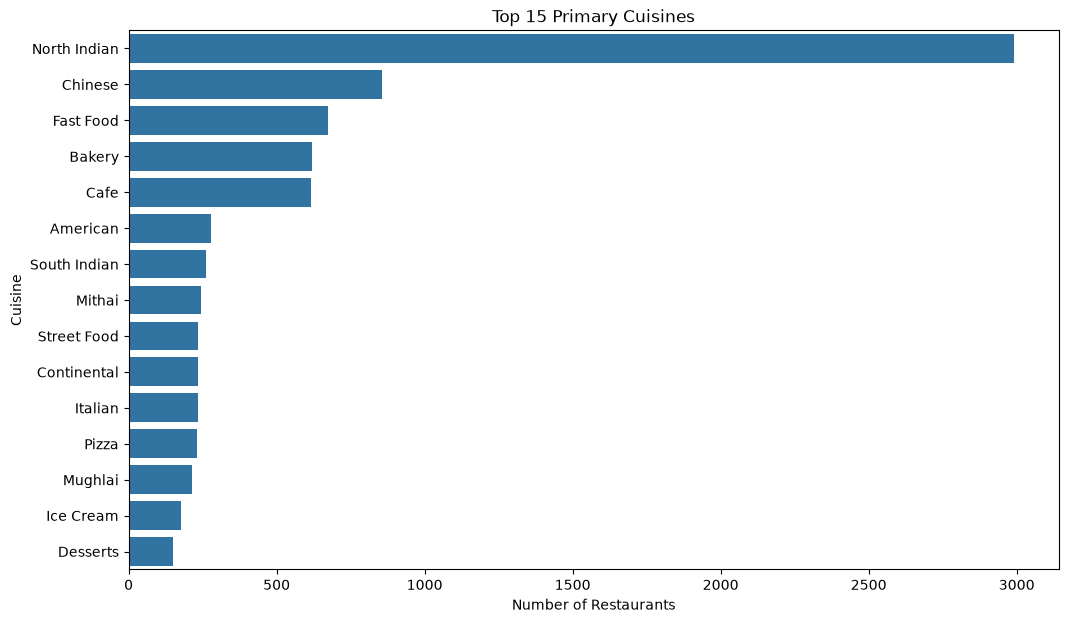

In [11]:
top_cuisines = (
    cuisine_counts
    .head(15)
)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_cuisines.values,
    y=top_cuisines.index
)

plt.title("Top 15 Primary Cuisines")
plt.xlabel("Number of Restaurants")
plt.ylabel("Cuisine")

plt.savefig(
    "../outputs/figures/task3_top_primary_cuisines.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()
plt.close()

In [12]:
MIN_SAMPLES = 50

rare_cuisines = cuisine_counts[
    cuisine_counts < MIN_SAMPLES
]

print(
    "Number of rare cuisine classes:",
    len(rare_cuisines)
)

print(
    "Restaurants in rare classes:",
    rare_cuisines.sum()
)

Number of rare cuisine classes: 94
Restaurants in rare classes: 653


In [13]:
df["Cuisine Class"] = np.where(
    df["Primary Cuisine"].map(cuisine_counts) < MIN_SAMPLES,
    "Other",
    df["Primary Cuisine"]
)

In [14]:
df["Cuisine Class"].value_counts().head(20)

Cuisine Class
North Indian    2992
Chinese          855
Fast Food        672
Other            653
Bakery           621
Cafe             617
American         278
South Indian     262
Mithai           246
Street Food      236
Continental      235
Italian          234
Pizza            232
Mughlai          215
Ice Cream        178
Desserts         150
Burger           116
Biryani          112
Raw Meats        110
Beverages         79
Name: count, dtype: int64

In [15]:
print(
    "Final number of classes:",
    df["Cuisine Class"].nunique()
)

Final number of classes: 27


In [16]:
final_counts = (
    df["Cuisine Class"]
    .value_counts()
)

final_counts

Cuisine Class
North Indian    2992
Chinese          855
Fast Food        672
Other            653
Bakery           621
Cafe             617
American         278
South Indian     262
Mithai           246
Street Food      236
Continental      235
Italian          234
Pizza            232
Mughlai          215
Ice Cream        178
Desserts         150
Burger           116
Biryani          112
Raw Meats        110
Beverages         79
Finger Food       78
Asian             77
Japanese          72
European          62
Mexican           62
Healthy Food      56
Indian            51
Name: count, dtype: int64

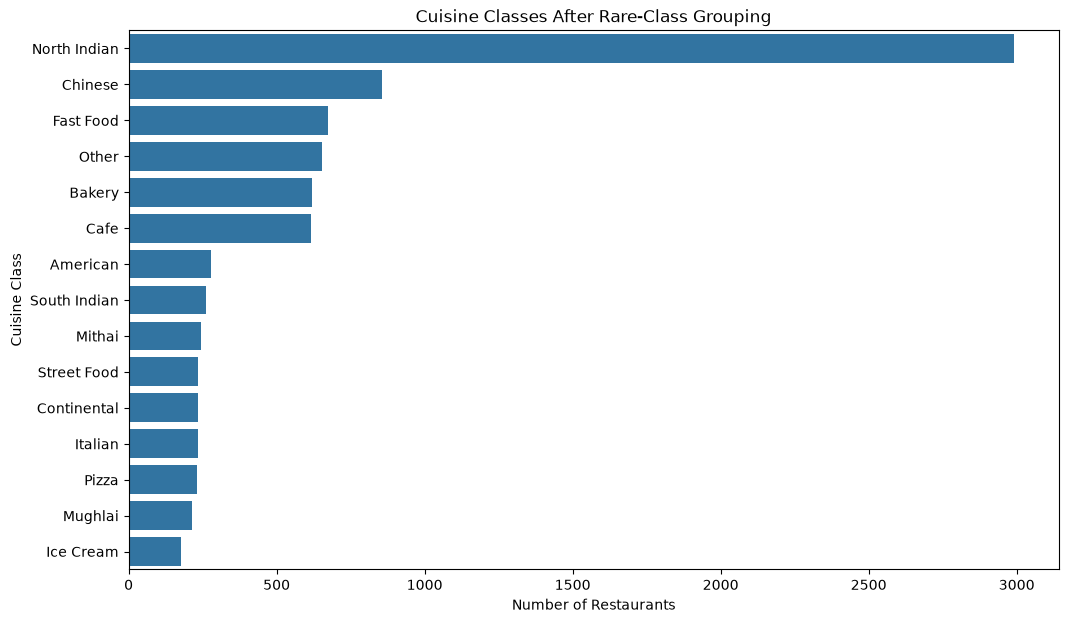

In [17]:
top_final = final_counts.head(15)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_final.values,
    y=top_final.index
)

plt.title("Cuisine Classes After Rare-Class Grouping")
plt.xlabel("Number of Restaurants")
plt.ylabel("Cuisine Class")

plt.savefig(
    "../outputs/figures/task3_final_class_distribution.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()
plt.close()

In [18]:
features = [
    "Country Code",
    "City",
    "Average Cost for two",
    "Currency",
    "Has Table booking",
    "Has Online delivery",
    "Is delivering now",
    "Price range",
    "Aggregate rating",
    "Votes",
    "Latitude",
    "Longitude"
]

In [19]:
target = "Cuisine Class"

In [20]:
X = df[features].copy()

y = df[target].copy()

In [21]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (9551, 12)
y shape: (9551,)


In [22]:
print("\nTarget distribution:")
print(y.value_counts())


Target distribution:
Cuisine Class
North Indian    2992
Chinese          855
Fast Food        672
Other            653
Bakery           621
Cafe             617
American         278
South Indian     262
Mithai           246
Street Food      236
Continental      235
Italian          234
Pizza            232
Mughlai          215
Ice Cream        178
Desserts         150
Burger           116
Biryani          112
Raw Meats        110
Beverages         79
Finger Food       78
Asian             77
Japanese          72
European          62
Mexican           62
Healthy Food      56
Indian            51
Name: count, dtype: int64


In [23]:
X.isnull().sum()

Country Code             0
City                     0
Average Cost for two    18
Currency                 0
Has Table booking        0
Has Online delivery      0
Is delivering now        0
Price range              0
Aggregate rating         0
Votes                    0
Latitude                 0
Longitude                0
dtype: int64

In [24]:
y.isnull().sum()

np.int64(0)

In [25]:
class_distribution = (
    y.value_counts(normalize=True) * 100
)

class_distribution.head(20).round(2)

Cuisine Class
North Indian    31.33
Chinese          8.95
Fast Food        7.04
Other            6.84
Bakery           6.50
Cafe             6.46
American         2.91
South Indian     2.74
Mithai           2.58
Street Food      2.47
Continental      2.46
Italian          2.45
Pizza            2.43
Mughlai          2.25
Ice Cream        1.86
Desserts         1.57
Burger           1.21
Biryani          1.17
Raw Meats        1.15
Beverages        0.83
Name: proportion, dtype: float64

In [26]:
print(
    "Unknown cuisine records:",
    (df["Cuisine Class"] == "Unknown").sum()
)

Unknown cuisine records: 0


In [27]:
df_classification = df[
    df["Cuisine Class"] != "Unknown"
].copy()

print(
    "Classification dataset shape:",
    df_classification.shape
)

Classification dataset shape: (9551, 23)


In [28]:
X = df_classification[features].copy()

y = df_classification[target].copy()

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [30]:
stratify=y

In [31]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 7640
Testing samples: 1911


In [32]:
print("Training classes:", y_train.nunique())
print("Testing classes:", y_test.nunique())

Training classes: 27
Testing classes: 27


In [33]:
train_distribution = (
    y_train.value_counts(normalize=True) * 100
).round(2)

test_distribution = (
    y_test.value_counts(normalize=True) * 100
).round(2)

distribution_comparison = pd.DataFrame({
    "Train %": train_distribution,
    "Test %": test_distribution
}).fillna(0)

distribution_comparison

,Train %,Test %
Cuisine Class,,
American,2.91,2.93
Asian,0.81,0.78
Bakery,6.51,6.49
Beverages,0.82,0.84
Biryani,1.18,1.15
Burger,1.22,1.20
Cafe,6.45,6.49
Chinese,8.95,8.95
Continental,2.46,2.46


In [34]:
df_classification.to_csv(
    "../outputs/results/task3_classification_dataset.csv",
    index=False
)

In [35]:
final_counts.to_csv(
    "../outputs/results/task3_class_distribution.csv"
)

In [36]:
X_train.to_csv(
    "../outputs/results/task3_X_train.csv",
    index=False
)

X_test.to_csv(
    "../outputs/results/task3_X_test.csv",
    index=False
)

y_train.to_csv(
    "../outputs/results/task3_y_train.csv",
    index=False
)

y_test.to_csv(
    "../outputs/results/task3_y_test.csv",
    index=False
)

In [37]:
MIN_SAMPLES = 50

# Day 10 — Task 3 Progress

## Work Completed

- Loaded the cleaned restaurant dataset.
- Examined the Cuisines column.
- Created a Primary Cuisine feature from the first cuisine listed
  for each restaurant.
- Analyzed the distribution of cuisine classes.
- Identified the presence of rare cuisine classes.
- Grouped cuisines with fewer than 50 observations into an
  "Other" category.
- Removed restaurants with an Unknown cuisine label from the
  classification dataset.
- Selected restaurant, location, service, price, rating, and
  popularity-related attributes as input features.
- Excluded Cuisines and Primary Cuisine from the input features
  to avoid target leakage.
- Created X and y for the classification problem.
- Performed a stratified 80/20 train-test split.
- Saved the prepared classification dataset and split data.

## Classification Target

The target variable is `Cuisine Class`.

## Next Step

Train and compare classification algorithms such as Logistic
Regression and Random Forest, followed by evaluation using
accuracy, precision, recall, F1-score, and a confusion matrix.

In [38]:
X
y
X_train
X_test
y_train
y_test

1870    Healthy Food
5479    North Indian
3685           Other
1090         Chinese
1163    North Indian
            ...     
3262            Cafe
5035    North Indian
1980    North Indian
4075          Bakery
7951          Mithai
Name: Cuisine Class, Length: 1911, dtype: str

In [39]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (7640, 12)
X_test : (1911, 12)
y_train: (7640,)
y_test : (1911,)


In [40]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [41]:
numeric_features = [
    "Average Cost for two",
    "Price range",
    "Aggregate rating",
    "Votes",
    "Latitude",
    "Longitude"
]

categorical_features = [
    "Country Code",
    "City",
    "Currency",
    "Has Table booking",
    "Has Online delivery",
    "Is delivering now"
]

In [42]:
print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Average Cost for two', 'Price range', 'Aggregate rating', 'Votes', 'Latitude', 'Longitude']

Categorical features:
['Country Code', 'City', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now']


In [43]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [44]:
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [45]:
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [46]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [47]:
logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced"
            )
        )
    ]
)

In [48]:
class_weight="balanced"

In [49]:
logistic_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](27,)","['American','Asian','Bakery',...,'Raw Meats','South Indian','Street Food']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['Country Code','City','Average Cost for two',...,'Votes','Latitude', 'Longitude']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns ar

In [50]:
logistic_pred = logistic_model.predict(
    X_test
)

In [51]:
print(logistic_pred[:20])

['Healthy Food' 'Beverages' 'Japanese' 'Mithai' 'Continental' 'Japanese'
 'Chinese' 'Beverages' 'Raw Meats' 'Mithai' 'Mithai' 'Mithai' 'Mexican'
 'Ice Cream' 'Healthy Food' 'European' 'Cafe' 'American' 'Biryani'
 'Italian']


In [52]:
random_forest_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=15,
                random_state=42,
                n_jobs=-1,
                class_weight="balanced"
            )
        )
    ]
)

In [53]:
random_forest_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](27,)","['American','Asian','Bakery',...,'Raw Meats','South Indian','Street Food']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['Country Code','City','Average Cost for two',...,'Votes','Latitude', 'Longitude']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns ar

In [54]:
random_forest_pred = random_forest_model.predict(
    X_test
)

In [55]:
print(random_forest_pred[:20])

['Healthy Food' 'Raw Meats' 'European' 'Ice Cream' 'Continental' 'Other'
 'North Indian' 'Street Food' 'Cafe' 'Raw Meats' 'Chinese' 'Chinese'
 'Japanese' 'Desserts' 'Healthy Food' 'American' 'Cafe' 'American'
 'Ice Cream' 'Italian']


In [56]:
logistic_accuracy = accuracy_score(
    y_test,
    logistic_pred
)

logistic_precision = precision_score(
    y_test,
    logistic_pred,
    average="weighted",
    zero_division=0
)

logistic_recall = recall_score(
    y_test,
    logistic_pred,
    average="weighted",
    zero_division=0
)

logistic_f1 = f1_score(
    y_test,
    logistic_pred,
    average="weighted",
    zero_division=0
)

print("Logistic Regression")
print("-------------------")
print("Accuracy :", round(logistic_accuracy, 4))
print("Precision:", round(logistic_precision, 4))
print("Recall   :", round(logistic_recall, 4))
print("F1 Score :", round(logistic_f1, 4))

Logistic Regression
-------------------
Accuracy : 0.09
Precision: 0.241
Recall   : 0.09
F1 Score : 0.0731


In [57]:
average="weighted"

In [58]:
rf_accuracy = accuracy_score(
    y_test,
    random_forest_pred
)

rf_precision = precision_score(
    y_test,
    random_forest_pred,
    average="weighted",
    zero_division=0
)

rf_recall = recall_score(
    y_test,
    random_forest_pred,
    average="weighted",
    zero_division=0
)

rf_f1 = f1_score(
    y_test,
    random_forest_pred,
    average="weighted",
    zero_division=0
)

print("Random Forest")
print("-------------")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1 Score :", round(rf_f1, 4))

Random Forest
-------------
Accuracy : 0.1638
Precision: 0.3302
Recall   : 0.1638
F1 Score : 0.1553


In [59]:
classification_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        rf_accuracy
    ],
    "Precision": [
        logistic_precision,
        rf_precision
    ],
    "Recall": [
        logistic_recall,
        rf_recall
    ],
    "F1 Score": [
        logistic_f1,
        rf_f1
    ]
})

In [60]:
classification_results = classification_results.round(4)

classification_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.0900,0.2410,0.0900,0.0731
1,Random Forest,0.1638,0.3302,0.1638,0.1553


In [61]:
classification_results.to_csv(
    "../outputs/results/task3_model_comparison.csv",
    index=False
)

In [62]:
best_model_name = classification_results.loc[
    classification_results["F1 Score"].idxmax(),
    "Model"
]

print("Best model based on weighted F1 Score:")
print(best_model_name)

Best model based on weighted F1 Score:
Random Forest


In [63]:
best_accuracy_model = classification_results.loc[
    classification_results["Accuracy"].idxmax(),
    "Model"
]

print(
    "Best model based on Accuracy:",
    best_accuracy_model
)

Best model based on Accuracy: Random Forest


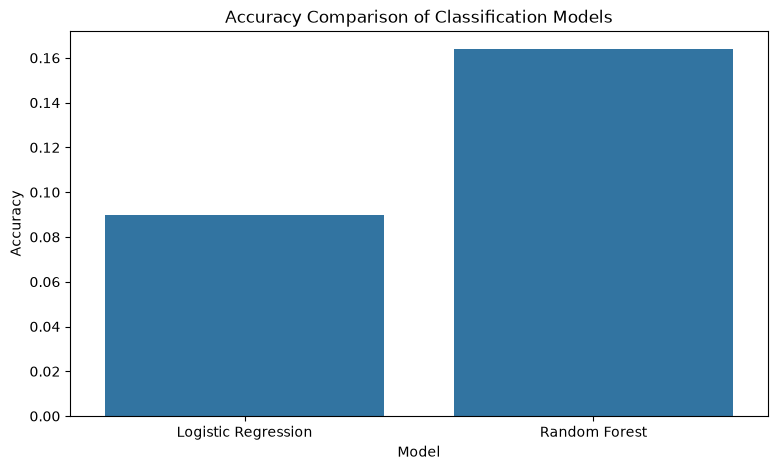

In [64]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=classification_results,
    x="Model",
    y="Accuracy"
)

plt.title("Accuracy Comparison of Classification Models")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.savefig(
    "../outputs/figures/task3_accuracy_comparison.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()
plt.close()

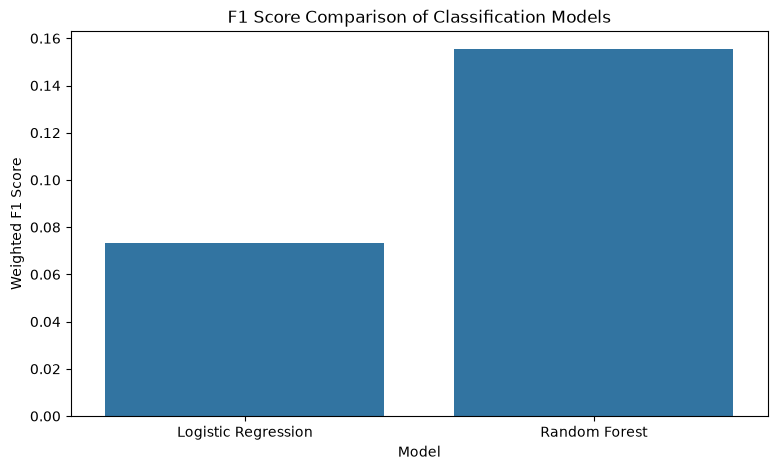

In [65]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=classification_results,
    x="Model",
    y="F1 Score"
)

plt.title("F1 Score Comparison of Classification Models")
plt.xlabel("Model")
plt.ylabel("Weighted F1 Score")

plt.savefig(
    "../outputs/figures/task3_f1_comparison.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()
plt.close()

In [66]:
predictions = {
    "Logistic Regression": logistic_pred,
    "Random Forest": random_forest_pred
}

best_predictions = predictions[best_model_name]

In [67]:
print(
    classification_report(
        y_test,
        best_predictions,
        zero_division=0
    )
)

              precision    recall  f1-score   support

    American       0.27      0.38      0.31        56
       Asian       0.06      0.13      0.08        15
      Bakery       0.23      0.12      0.16       124
   Beverages       0.04      0.12      0.06        16
     Biryani       0.02      0.05      0.03        22
      Burger       0.10      0.17      0.13        23
        Cafe       0.28      0.30      0.29       124
     Chinese       0.14      0.03      0.05       171
 Continental       0.14      0.36      0.21        47
    Desserts       0.14      0.20      0.17        30
    European       0.06      0.17      0.08        12
   Fast Food       0.19      0.05      0.08       135
 Finger Food       0.18      0.62      0.27        16
Healthy Food       0.07      0.45      0.12        11
   Ice Cream       0.12      0.36      0.18        36
      Indian       0.38      0.60      0.46        10
     Italian       0.13      0.21      0.16        47
    Japanese       0.14    

In [68]:
report = classification_report(
    y_test,
    best_predictions,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).T

report_df.round(4)

,precision,recall,f1-score,support
American,0.2692,0.3750,0.3134,56.0000
Asian,0.0571,0.1333,0.0800,15.0000
Bakery,0.2273,0.1210,0.1579,124.0000
Beverages,0.0392,0.1250,0.0597,16.0000
Biryani,0.0196,0.0455,0.0274,22.0000
Burger,0.1000,0.1739,0.1270,23.0000
Cafe,0.2803,0.2984,0.2891,124.0000
Chinese,0.1351,0.0292,0.0481,171.0000
Continental,0.1441,0.3617,0.2061,47.0000
Desserts,0.1429,0.2000,0.1667,30.0000


In [69]:
report_df.to_csv(
    "../outputs/results/task3_classification_report.csv"
)

In [70]:
class_report = report_df[
    ~report_df.index.isin(
        ["accuracy", "macro avg", "weighted avg"]
    )
].copy()

In [71]:
weakest_classes = class_report.sort_values(
    "f1-score",
    ascending=True
)

weakest_classes.head(10)

,precision,recall,f1-score,support
Mughlai,0.016129,0.046512,0.023952,43.0
Biryani,0.019608,0.045455,0.027397,22.0
Chinese,0.135135,0.029240,0.048077,171.0
Beverages,0.039216,0.125000,0.059701,16.0
Asian,0.057143,0.133333,0.080000,15.0
Fast Food,0.189189,0.051852,0.081395,135.0
European,0.055556,0.166667,0.083333,12.0
South Indian,0.087719,0.094340,0.090909,53.0
Mexican,0.076923,0.166667,0.105263,12.0
North Indian,0.615385,0.066778,0.120482,599.0


In [72]:
strongest_classes = class_report.sort_values(
    "f1-score",
    ascending=False
)

strongest_classes.head(10)

,precision,recall,f1-score,support
Indian,0.375000,0.600000,0.461538,10.0
American,0.269231,0.375000,0.313433,56.0
Other,0.500000,0.213740,0.299465,131.0
Cafe,0.280303,0.298387,0.289062,124.0
Street Food,0.254237,0.319149,0.283019,47.0
Finger Food,0.175439,0.625000,0.273973,16.0
Mithai,0.162162,0.489796,0.243655,49.0
Pizza,0.145299,0.369565,0.208589,46.0
Continental,0.144068,0.361702,0.206061,47.0
Ice Cream,0.119266,0.361111,0.179310,36.0


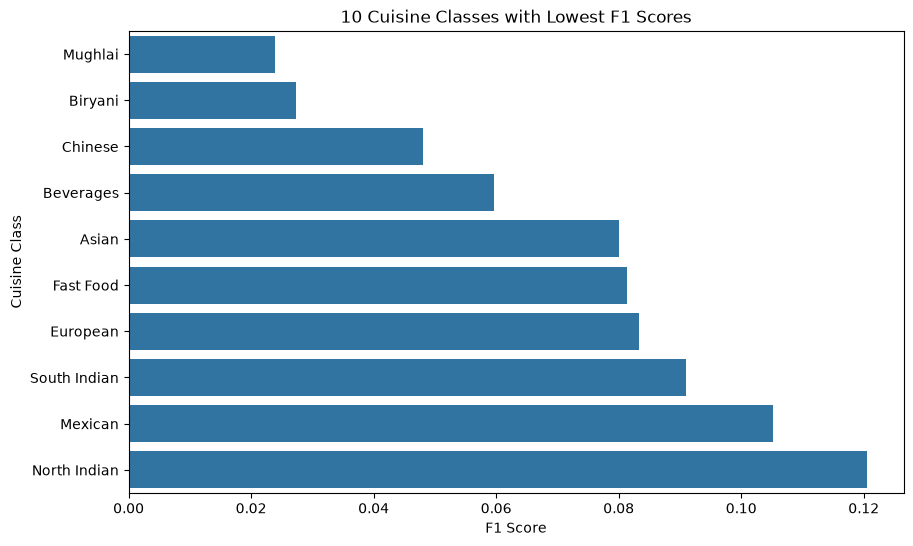

In [73]:
weakest_plot = weakest_classes.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=weakest_plot,
    x="f1-score",
    y=weakest_plot.index
)

plt.title("10 Cuisine Classes with Lowest F1 Scores")
plt.xlabel("F1 Score")
plt.ylabel("Cuisine Class")

plt.savefig(
    "../outputs/figures/task3_weakest_cuisines.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()
plt.close()

In [74]:
cm = confusion_matrix(
    y_test,
    best_predictions,
    labels=sorted(y_test.unique())
)

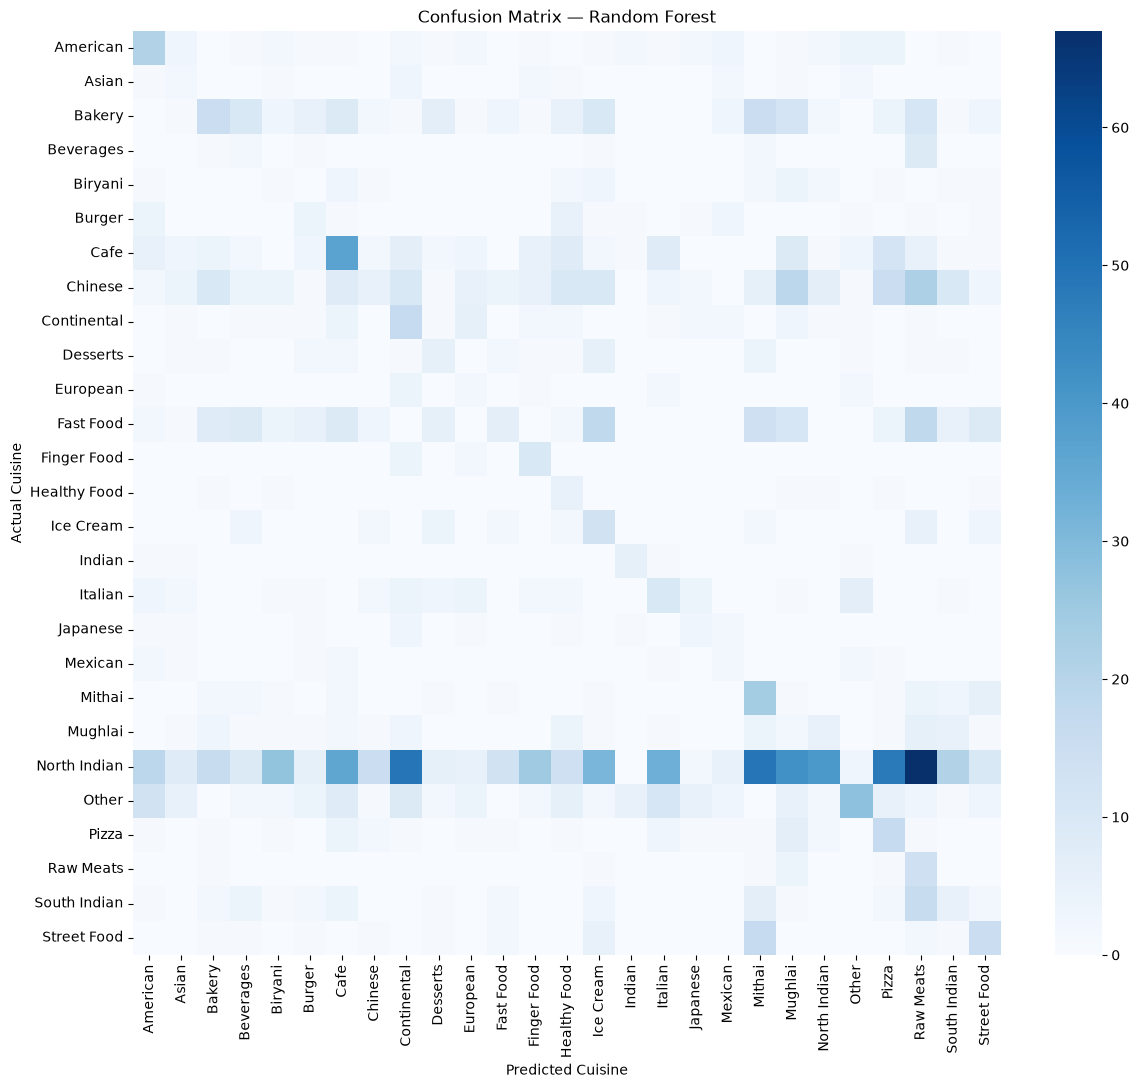

In [75]:
plt.figure(
    figsize=(14, 12)
)

sns.heatmap(
    cm,
    annot=False,
    cmap="Blues",
    xticklabels=sorted(y_test.unique()),
    yticklabels=sorted(y_test.unique())
)

plt.title(
    f"Confusion Matrix — {best_model_name}"
)

plt.xlabel("Predicted Cuisine")
plt.ylabel("Actual Cuisine")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.savefig(
    "../outputs/figures/task3_confusion_matrix.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()
plt.close()

In [76]:
class_counts = y.value_counts()

class_imbalance = pd.DataFrame({
    "Cuisine Class": class_counts.index,
    "Count": class_counts.values,
    "Percentage": (
        class_counts.values /
        class_counts.sum() * 100
    )
})

class_imbalance.head(20)

,Cuisine Class,Count,Percentage
0,North Indian,2992,31.326563
1,Chinese,855,8.951942
2,Fast Food,672,7.035912
3,Other,653,6.836980
4,Bakery,621,6.501937
5,Cafe,617,6.460057
6,American,278,2.910690
7,South Indian,262,2.743168
8,Mithai,246,2.575647
9,Street Food,236,2.470945


In [77]:
class_imbalance.to_csv(
    "../outputs/results/task3_class_imbalance.csv",
    index=False
)

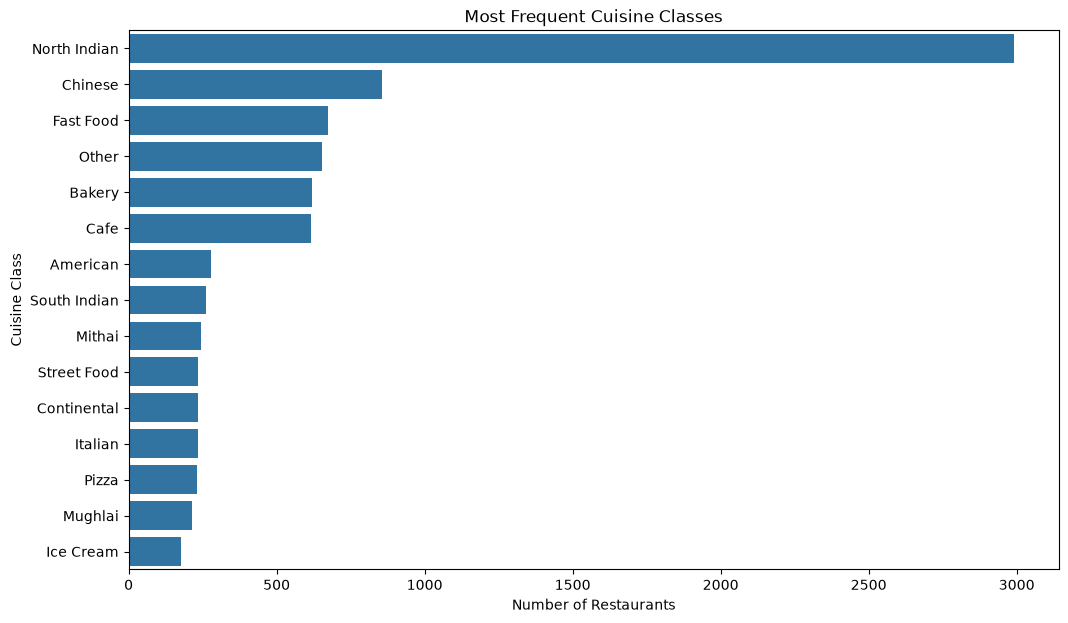

In [78]:
top_classes = class_imbalance.head(15)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_classes,
    x="Count",
    y="Cuisine Class"
)

plt.title("Most Frequent Cuisine Classes")
plt.xlabel("Number of Restaurants")
plt.ylabel("Cuisine Class")

plt.savefig(
    "../outputs/figures/task3_class_imbalance.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()
plt.close()

# Day 11 — Model Training and Evaluation

Two classification models were trained:

1. Logistic Regression
2. Random Forest Classifier

A preprocessing pipeline was used to handle numerical and
categorical features separately.

### Numerical preprocessing
- Median imputation
- Standard scaling

### Categorical preprocessing
- Most-frequent imputation
- One-hot encoding

The models were trained using the stratified training dataset.

### Evaluation Metrics

The models were evaluated using:

- Accuracy
- Weighted Precision
- Weighted Recall
- Weighted F1 Score

A classification report and confusion matrix were also used
to analyze performance across individual cuisine classes.

# Task 3 — Preliminary Conclusion

The cuisine classification problem was formulated as a
multiclass classification problem using the primary cuisine
as the target variable.

Logistic Regression and Random Forest were trained using a
common preprocessing pipeline. Their performances were compared
using accuracy, weighted precision, weighted recall, and
weighted F1 score.

Individual-class performance was also examined using the
classification report and confusion matrix.

The analysis will be used to identify well-performing and
poorly-performing cuisine classes and investigate the effect
of class imbalance on the model.

In [79]:
X_train
X_test
y_train
y_test
logistic_model
random_forest_model
logistic_pred
random_forest_pred
classification_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.0900,0.2410,0.0900,0.0731
1,Random Forest,0.1638,0.3302,0.1638,0.1553


In [80]:
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)
print("Classes:", y.nunique())

Training shape: (7640, 12)
Testing shape: (1911, 12)
Classes: 27


In [81]:
classification_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.0900,0.2410,0.0900,0.0731
1,Random Forest,0.1638,0.3302,0.1638,0.1553


In [82]:
classification_results.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
1,Random Forest,0.1638,0.3302,0.1638,0.1553
0,Logistic Regression,0.0900,0.2410,0.0900,0.0731


In [83]:
best_model_name = classification_results.loc[
    classification_results["F1 Score"].idxmax(),
    "Model"
]

print("Selected final model:", best_model_name)

Selected final model: Random Forest


In [84]:
predictions = {
    "Logistic Regression": logistic_pred,
    "Random Forest": random_forest_pred
}

best_predictions = predictions[best_model_name]

In [85]:
print("Final model:", best_model_name)

Final model: Random Forest


In [86]:
final_report = classification_report(
    y_test,
    best_predictions,
    output_dict=True,
    zero_division=0
)

final_report_df = pd.DataFrame(final_report).T

final_report_df.round(4)

,precision,recall,f1-score,support
American,0.2692,0.3750,0.3134,56.0000
Asian,0.0571,0.1333,0.0800,15.0000
Bakery,0.2273,0.1210,0.1579,124.0000
Beverages,0.0392,0.1250,0.0597,16.0000
Biryani,0.0196,0.0455,0.0274,22.0000
Burger,0.1000,0.1739,0.1270,23.0000
Cafe,0.2803,0.2984,0.2891,124.0000
Chinese,0.1351,0.0292,0.0481,171.0000
Continental,0.1441,0.3617,0.2061,47.0000
Desserts,0.1429,0.2000,0.1667,30.0000


In [87]:
final_report_df.to_csv(
    "../outputs/results/task3_final_classification_report.csv"
)

In [88]:
class_report = final_report_df[
    ~final_report_df.index.isin(
        ["accuracy", "macro avg", "weighted avg"]
    )
].copy()

In [89]:
best_cuisines = class_report.sort_values(
    by="f1-score",
    ascending=False
).head(10)

best_cuisines

,precision,recall,f1-score,support
Indian,0.375000,0.600000,0.461538,10.0
American,0.269231,0.375000,0.313433,56.0
Other,0.500000,0.213740,0.299465,131.0
Cafe,0.280303,0.298387,0.289062,124.0
Street Food,0.254237,0.319149,0.283019,47.0
Finger Food,0.175439,0.625000,0.273973,16.0
Mithai,0.162162,0.489796,0.243655,49.0
Pizza,0.145299,0.369565,0.208589,46.0
Continental,0.144068,0.361702,0.206061,47.0
Ice Cream,0.119266,0.361111,0.179310,36.0


In [90]:
worst_cuisines = class_report.sort_values(
    by="f1-score",
    ascending=True
).head(10)

worst_cuisines

,precision,recall,f1-score,support
Mughlai,0.016129,0.046512,0.023952,43.0
Biryani,0.019608,0.045455,0.027397,22.0
Chinese,0.135135,0.029240,0.048077,171.0
Beverages,0.039216,0.125000,0.059701,16.0
Asian,0.057143,0.133333,0.080000,15.0
Fast Food,0.189189,0.051852,0.081395,135.0
European,0.055556,0.166667,0.083333,12.0
South Indian,0.087719,0.094340,0.090909,53.0
Mexican,0.076923,0.166667,0.105263,12.0
North Indian,0.615385,0.066778,0.120482,599.0


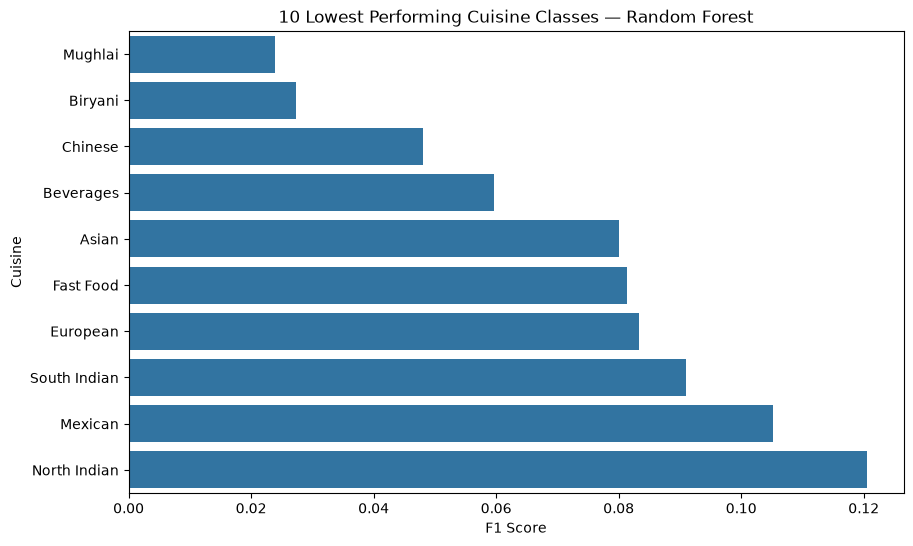

In [91]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=worst_cuisines,
    x="f1-score",
    y=worst_cuisines.index
)

plt.title(
    f"10 Lowest Performing Cuisine Classes — {best_model_name}"
)
plt.xlabel("F1 Score")
plt.ylabel("Cuisine")

plt.savefig(
    "../outputs/figures/task3_lowest_performing_cuisines.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()
plt.close()

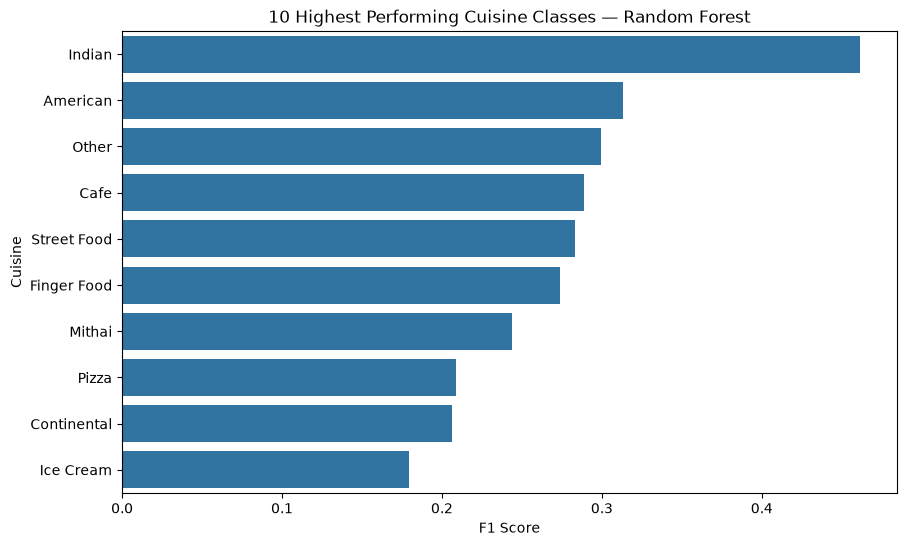

In [92]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=best_cuisines,
    x="f1-score",
    y=best_cuisines.index
)

plt.title(
    f"10 Highest Performing Cuisine Classes — {best_model_name}"
)
plt.xlabel("F1 Score")
plt.ylabel("Cuisine")

plt.savefig(
    "../outputs/figures/task3_highest_performing_cuisines.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()
plt.close()

In [93]:
class_analysis = class_report.copy()

class_analysis["Cuisine"] = class_analysis.index

class_analysis = class_analysis.merge(
    class_imbalance,
    left_on="Cuisine",
    right_on="Cuisine Class",
    how="left"
)

class_analysis[
    [
        "Cuisine",
        "Count",
        "Percentage",
        "precision",
        "recall",
        "f1-score"
    ]
].sort_values(
    "f1-score"
).head(15)

,Cuisine,Count,Percentage,precision,recall,f1-score
20,Mughlai,215,2.251073,0.016129,0.046512,0.023952
4,Biryani,112,1.172652,0.019608,0.045455,0.027397
7,Chinese,855,8.951942,0.135135,0.029240,0.048077
3,Beverages,79,0.827139,0.039216,0.125000,0.059701
1,Asian,77,0.806198,0.057143,0.133333,0.080000
11,Fast Food,672,7.035912,0.189189,0.051852,0.081395
10,European,62,0.649147,0.055556,0.166667,0.083333
25,South Indian,262,2.743168,0.087719,0.094340,0.090909
18,Mexican,62,0.649147,0.076923,0.166667,0.105263
21,North Indian,2992,31.326563,0.615385,0.066778,0.120482


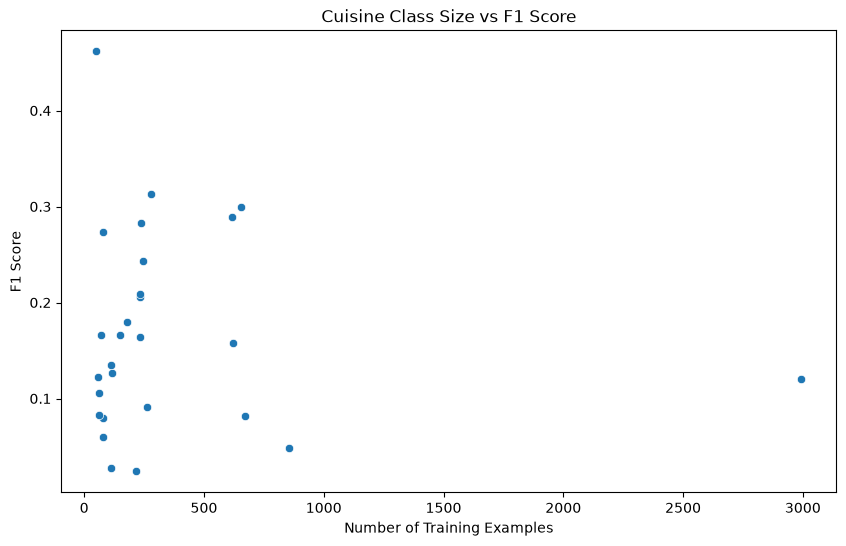

In [94]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=class_analysis,
    x="Count",
    y="f1-score"
)

plt.title(
    "Cuisine Class Size vs F1 Score"
)
plt.xlabel("Number of Training Examples")
plt.ylabel("F1 Score")

plt.savefig(
    "../outputs/figures/task3_class_size_vs_f1.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()
plt.close()

In [95]:
class_imbalance.sort_values(
    by="Count",
    ascending=True
).head(15)

,Cuisine Class,Count,Percentage
26,Indian,51,0.533975
25,Healthy Food,56,0.586326
24,Mexican,62,0.649147
23,European,62,0.649147
22,Japanese,72,0.753848
21,Asian,77,0.806198
20,Finger Food,78,0.816668
19,Beverages,79,0.827139
18,Raw Meats,110,1.151712
17,Biryani,112,1.172652


In [96]:
largest_class = class_imbalance.iloc[0]

smallest_class = class_imbalance.sort_values(
    "Count"
).iloc[0]

print("Largest class:")
print(largest_class)

print("\nSmallest class:")
print(smallest_class)

Largest class:
Cuisine Class    North Indian
Count                    2992
Percentage          31.326563
Name: 0, dtype: object

Smallest class:
Cuisine Class      Indian
Count                  51
Percentage       0.533975
Name: 26, dtype: object


In [97]:
labels = sorted(y_test.unique())

cm = confusion_matrix(
    y_test,
    best_predictions,
    labels=labels
)

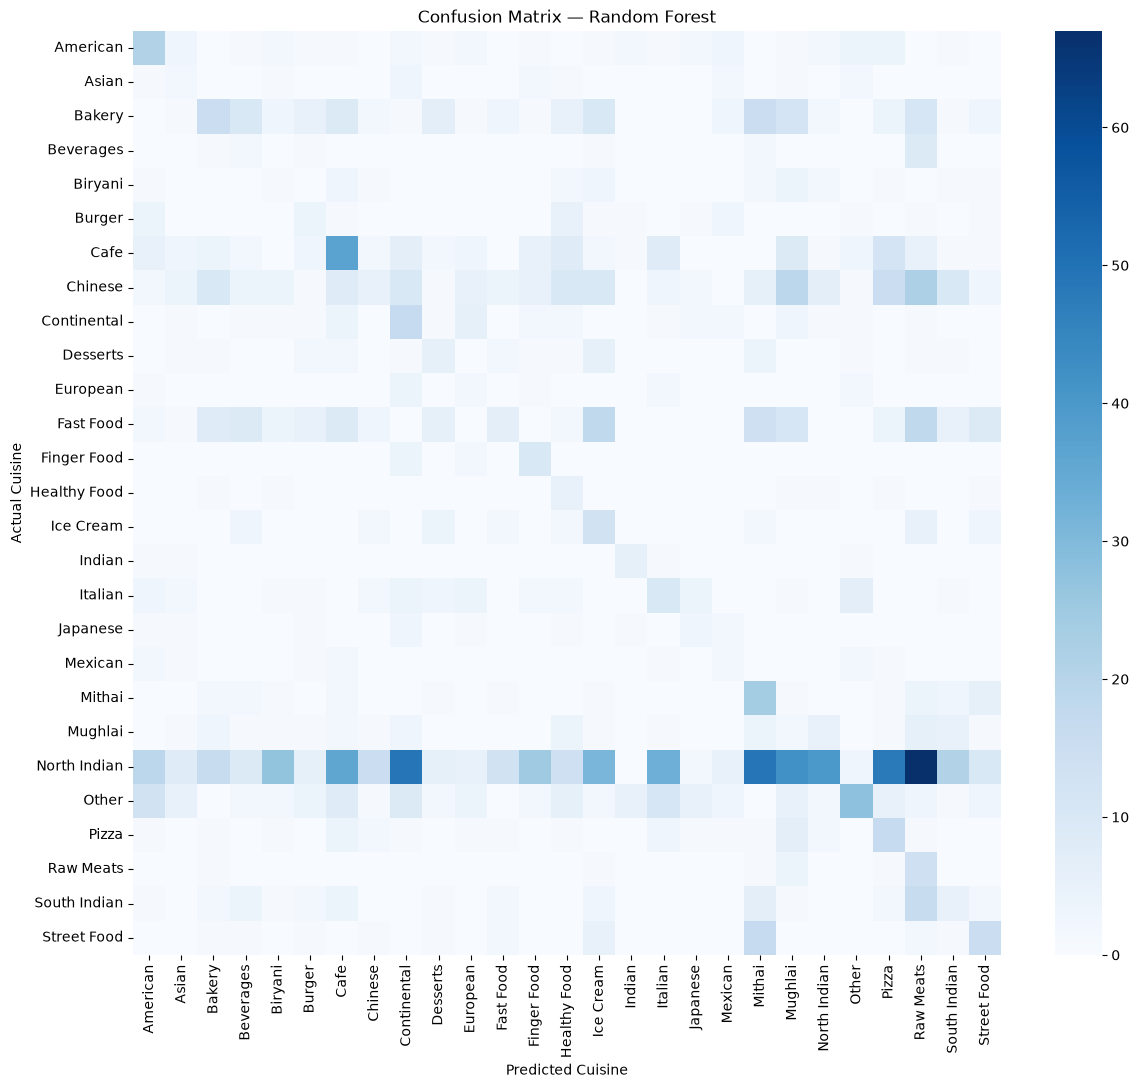

In [98]:
plt.figure(figsize=(14, 12))

sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    annot=False
)

plt.title(
    f"Confusion Matrix — {best_model_name}"
)

plt.xlabel("Predicted Cuisine")
plt.ylabel("Actual Cuisine")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.savefig(
    "../outputs/figures/task3_final_confusion_matrix.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()
plt.close()

In [99]:
confusion_df = pd.DataFrame(
    cm,
    index=labels,
    columns=labels
)

In [100]:
off_diagonal = confusion_df.copy()

for label in labels:
    off_diagonal.loc[label, label] = 0

In [101]:
misclassifications = (
    off_diagonal
    .stack()
    .sort_values(ascending=False)
)

misclassifications.head(15)

North Indian  Raw Meats       67
              Mithai          49
              Continental     49
              Pizza           48
              Mughlai         42
              Cafe            36
              Italian         33
              Ice Cream       31
              Biryani         27
              Finger Food     25
Chinese       Raw Meats       22
North Indian  South Indian    21
              American        19
Chinese       Mughlai         19
Fast Food     Ice Cream       18
dtype: int64

In [102]:
rf_preprocessor = random_forest_model.named_steps[
    "preprocessor"
]

rf_model = random_forest_model.named_steps[
    "model"
]

In [103]:
rf_feature_names = (
    rf_preprocessor
    .get_feature_names_out()
)

In [104]:
rf_importance = pd.DataFrame({
    "Feature": rf_feature_names,
    "Importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    "Importance",
    ascending=False
)

In [105]:
rf_importance.head(20)

,Feature,Importance
0,num__Average Cost for two,0.155590
4,num__Latitude,0.146475
5,num__Longitude,0.143772
3,num__Votes,0.140322
2,num__Aggregate rating,0.119268
1,num__Price range,0.064843
164,cat__Has Online delivery_Yes,0.015356
163,cat__Has Online delivery_No,0.015164
162,cat__Has Table booking_Yes,0.014951
161,cat__Has Table booking_No,0.014423


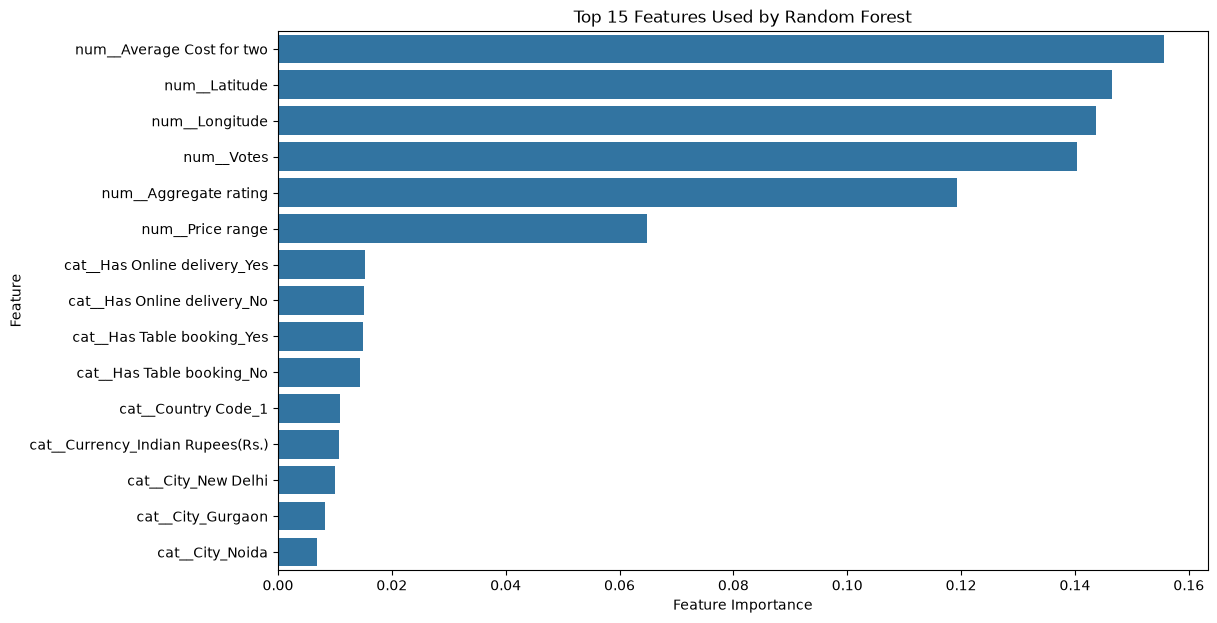

In [106]:
top_rf_features = rf_importance.head(15)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_rf_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 15 Features Used by Random Forest"
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.savefig(
    "../outputs/figures/task3_feature_importance.png",
    bbox_inches="tight",
    dpi=300
)

plt.show()
plt.close()

In [107]:
rf_importance.to_csv(
    "../outputs/results/task3_feature_importance.csv",
    index=False
)

In [108]:
error_analysis = X_test.copy()

error_analysis["Actual Cuisine"] = y_test.values
error_analysis["Predicted Cuisine"] = best_predictions

error_analysis["Correct"] = (
    error_analysis["Actual Cuisine"]
    == error_analysis["Predicted Cuisine"]
)

In [109]:
error_analysis.head()

,Country Code,City,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Price range,Aggregate rating,Votes,Latitude,Longitude,Actual Cuisine,Predicted Cuisine,Correct
1870,1,Gurgaon,650.0,Indian Rupees(Rs.),No,Yes,No,2,3.8,99,28.459874,77.055340,Healthy Food,Healthy Food,True
5479,1,New Delhi,400.0,Indian Rupees(Rs.),No,No,No,1,3.4,33,28.656862,77.146720,North Indian,Raw Meats,False
3685,1,New Delhi,2000.0,Indian Rupees(Rs.),Yes,Yes,No,4,3.8,223,28.556472,77.233465,Other,European,False
1090,1,Faridabad,300.0,Indian Rupees(Rs.),No,No,No,1,0.0,2,28.376457,77.332812,Chinese,Ice Cream,False
1163,1,Gurgaon,2000.0,Indian Rupees(Rs.),Yes,Yes,No,4,4.3,1887,28.503077,77.097118,North Indian,Continental,False


In [110]:
wrong_predictions = error_analysis[
    error_analysis["Correct"] == False
]

print(
    "Incorrect predictions:",
    len(wrong_predictions)
)

print(
    "Total test samples:",
    len(error_analysis)
)

Incorrect predictions: 1598
Total test samples: 1911


In [111]:
error_rate = (
    len(wrong_predictions) /
    len(error_analysis)
)

print(
    "Error rate:",
    round(error_rate, 4)
)

Error rate: 0.8362


In [112]:
wrong_predictions[
    [
        "Actual Cuisine",
        "Predicted Cuisine",
        "City",
        "Price range",
        "Aggregate rating",
        "Votes"
    ]
].head(20)

,Actual Cuisine,Predicted Cuisine,City,Price range,Aggregate rating,Votes
5479,North Indian,Raw Meats,New Delhi,1,3.4,33
3685,Other,European,New Delhi,4,3.8,223
1090,Chinese,Ice Cream,Faridabad,1,0.0,2
1163,North Indian,Continental,Gurgaon,4,4.3,1887
1851,North Indian,Other,Gurgaon,3,3.6,302
1166,Ice Cream,Street Food,Gurgaon,1,3.0,5
7590,Chinese,Raw Meats,New Delhi,1,0.0,1
2721,Ice Cream,Chinese,New Delhi,1,0.0,0
28,Other,Japanese,Bras�_lia,3,3.7,8
7791,Fast Food,Desserts,New Delhi,1,3.7,32


In [113]:
logistic_train_pred = logistic_model.predict(X_train)

logistic_train_accuracy = accuracy_score(
    y_train,
    logistic_train_pred
)

logistic_test_accuracy = accuracy_score(
    y_test,
    logistic_pred
)

print("Logistic Regression")
print(
    "Train Accuracy:",
    round(logistic_train_accuracy, 4)
)
print(
    "Test Accuracy :",
    round(logistic_test_accuracy, 4)
)

Logistic Regression
Train Accuracy: 0.1094
Test Accuracy : 0.09


In [114]:
rf_train_pred = random_forest_model.predict(X_train)

rf_train_accuracy = accuracy_score(
    y_train,
    rf_train_pred
)

rf_test_accuracy = accuracy_score(
    y_test,
    random_forest_pred
)

print("Random Forest")
print(
    "Train Accuracy:",
    round(rf_train_accuracy, 4)
)
print(
    "Test Accuracy :",
    round(rf_test_accuracy, 4)
)

Random Forest
Train Accuracy: 0.5041
Test Accuracy : 0.1638


In [115]:
train_test_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Train Accuracy": [
        logistic_train_accuracy,
        rf_train_accuracy
    ],
    "Test Accuracy": [
        logistic_test_accuracy,
        rf_test_accuracy
    ]
})

train_test_results.round(4)

,Model,Train Accuracy,Test Accuracy
0,Logistic Regression,0.1094,0.0900
1,Random Forest,0.5041,0.1638


In [116]:
train_test_results.to_csv(
    "../outputs/results/task3_train_test_accuracy.csv",
    index=False
)

# Task 3 — Final Methodology

The cuisine classification problem was formulated as a multiclass
classification task.

The first cuisine listed in the original Cuisines column was
used as the Primary Cuisine. Cuisine classes with fewer than
50 observations were grouped into the Other category to reduce
the effect of extremely rare classes.

The input features included location, cost, price range,
restaurant services, ratings, and votes. The original Cuisines
and Primary Cuisine fields were excluded from the input features
to prevent target leakage.

Numerical features were processed using median imputation and
standardization. Categorical features were processed using
most-frequent imputation and one-hot encoding.

Logistic Regression and Random Forest Classifier were trained
using a stratified 80/20 train-test split.

Model performance was evaluated using accuracy, weighted
precision, weighted recall, weighted F1 score, classification
reports, and a confusion matrix.

# Task 3 — Final Analysis

The classification models were compared using accuracy,
precision, recall, and weighted F1 score.

The final model was selected based on its performance on the
held-out test dataset.

Cuisine-wise evaluation showed that model performance was not
uniform across all classes. Frequent cuisine classes generally
had more training examples, while some less-represented classes
were more difficult to classify.

The confusion matrix was used to identify common
misclassifications between cuisine classes.

Feature importance from the Random Forest model was analyzed
to identify restaurant attributes that contributed most strongly
to the classification predictions.

## Limitations

1. The dataset contains imbalanced cuisine classes, which can
   affect classification performance across different cuisines.

2. The classification target was simplified to the primary
   cuisine rather than the complete cuisine combination.

3. Rare cuisine classes were grouped into an Other category,
   reducing classification granularity.

4. The model uses only the attributes available in the dataset.
   Other factors that may distinguish cuisines are not included.

5. Geographic concentration in the dataset may influence model
   predictions and limit generalization to locations that are
   less represented.

6. Classification performance should therefore be interpreted
   together with class-wise metrics rather than accuracy alone.

# Task 3 — Conclusion

A multiclass machine learning system was developed to classify
restaurants according to their primary cuisine.

Logistic Regression and Random Forest were trained and evaluated
using a stratified train-test split. Accuracy, precision, recall,
and F1 score were used to compare the models.

The final model was selected based on its test-set performance.
Cuisine-wise analysis, the classification report, and confusion
matrix were used to identify strengths and weaknesses across
different cuisine classes.

The analysis also highlighted challenges associated with class
imbalance, rare cuisine categories, geographic concentration,
and the simplification of multi-cuisine restaurants into a
single primary cuisine class.

Overall, the project demonstrates how restaurant attributes such
as location, pricing, services, ratings, and popularity can be
used to build a machine learning approach for cuisine
classification.

In [2]:
target = "Cuisine Class"

In [3]:
features = [
    "Country Code",
    "City",
    "Average Cost for two",
    "Currency",
    "Has Table booking",
    "Has Online delivery",
    "Is delivering now",
    "Price range",
    "Aggregate rating",
    "Votes",
    "Latitude",
    "Longitude"
]

In [5]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    "../outputs/results/cleaned_restaurant_dataset.csv"
)

print(df.shape)

(9551, 22)


In [6]:
df["Primary Cuisine"] = (
    df["Cuisines"]
    .fillna("Unknown")
    .astype(str)
    .str.split(",")
    .str[0]
    .str.strip()
    .str.title()
)

In [7]:
cuisine_counts = df["Primary Cuisine"].value_counts()

print(
    "Number of cuisine classes:",
    df["Primary Cuisine"].nunique()
)

Number of cuisine classes: 120


In [8]:
MIN_SAMPLES = 50

df["Cuisine Class"] = np.where(
    df["Primary Cuisine"].map(cuisine_counts) < MIN_SAMPLES,
    "Other",
    df["Primary Cuisine"]
)

In [9]:
df_classification = df[
    df["Cuisine Class"] != "Unknown"
].copy()

print(
    "Classification dataset shape:",
    df_classification.shape
)

Classification dataset shape: (9551, 23)


In [10]:
target = "Cuisine Class"

features = [
    "Country Code",
    "City",
    "Average Cost for two",
    "Currency",
    "Has Table booking",
    "Has Online delivery",
    "Is delivering now",
    "Price range",
    "Aggregate rating",
    "Votes",
    "Latitude",
    "Longitude"
]

In [11]:
X = df_classification[features].copy()

y = df_classification[target].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (9551, 12)
y shape: (9551,)


In [12]:
leakage_columns = [
    "Cuisines",
    "Primary Cuisine",
    "Cuisine Class"
]

leakage_found = [
    col for col in leakage_columns
    if col in X.columns
]

print("Leakage columns found:", leakage_found)

Leakage columns found: []
